# Mô-đun 5: What-if Analysis & Career Recourse System

**Đồ án:** Hệ hỗ trợ quyết định trong định giá lương và tư vấn đàm phán lương  
**Module:** What-if Analysis — Counterfactual Explanation & Algorithmic Recourse  
**Mục tiêu:** Trả lời câu hỏi *"Ứng viên cần thay đổi gì để đạt mức lương mong muốn?"*

---

## Tổng quan kiến trúc

```
Đầu vào: Hồ sơ hiện tại + target_salary + risk_preference
        ↓
┌──────────────────────────────────────────────────────────────┐
│  BƯỚC 1 — Nhận hồ sơ và target_salary                       │
│  BƯỚC 2 — Gọi Module 1 lấy Q50 hiện tại                     │
│  BƯỚC 3 — Kiểm tra: Q50 >= target? → No change needed       │
│  BƯỚC 4 — Xác định actionable features                       │
│  BƯỚC 5 — Sinh kịch bản what-if đơn biến                    │
│  BƯỚC 6 — Sinh kịch bản tổ hợp (Counterfactual Optim.)      │
│  BƯỚC 7 — Loại kịch bản vi phạm ràng buộc                   │
│  BƯỚC 8 — Xếp hạng: expected_gain × feasibility / cost      │
│  BƯỚC 9 — Sinh lộ trình hành động (Action Roadmap)          │
│  BƯỚC 10 — Xuất kết quả cho chatbot/giải thích              │
└──────────────────────────────────────────────────────────────┘
        ↓
Đầu ra: ranked_scenarios, action_roadmap, whatif_report.json
```

## Các bước chính

1. Import & cấu hình  
2. Load toàn bộ model từ Module 1–4  
3. Bước 1–3: Nhận hồ sơ, tính Q50 baseline, kiểm tra gap  
4. Bước 4: Xác định actionable features và không gian tìm kiếm  
5. Bước 5: What-if đơn biến (single-feature perturbation)  
6. Bước 6: Counterfactual optimization (tổ hợp đa biến)  
7. Bước 7: Constraint filtering  
8. Bước 8: Ranking theo composite score  
9. Bước 9: Action Roadmap (lộ trình theo thời gian)  
10. Bước 10: Export & Visualization tổng hợp  


## 1. Import thư viện & cấu hình

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import scipy.sparse as sp
import warnings
import os
import json
import itertools
from typing import Dict, List, Tuple, Optional, Any
from copy import deepcopy

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11

# ── Thư mục ───────────────────────────────────────────────────────────────────
FIGURE_DIR  = 'figure/WhatIf'
OUTPUT_DIR  = 'whatif_outputs'
DATA_DIR    = 'preprocessing_salary_outputs'

os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("✅ Thư viện đã sẵn sàng.")
print(f"   Figure dir : {FIGURE_DIR}")
print(f"   Output dir : {OUTPUT_DIR}")


✅ Thư viện đã sẵn sàng.
   Figure dir : figure/WhatIf
   Output dir : whatif_outputs


## 2. Load toàn bộ model từ Module 1–4

Module 5 tái sử dụng:
- **Module 1**: `preprocessor.joblib` + `model_lgbm_p50.joblib` (dự đoán Q50)
- **Module 2**: `knn_scaler.joblib` + `knn_nn_engine.joblib` (peer lookup)
- **Module 3**: `offer_assessment_model.pkl` (đánh giá offer quality)
- **Module 4**: `negotiation_optimizer.pkl` (W1_STAR, W2_STAR, steepness config)


In [2]:
# ── Module 1: preprocessor + LGBM quantile models ────────────────────────────
preprocessor   = joblib.load(f'{DATA_DIR}/preprocessor.joblib')
model_lgbm     = joblib.load('model_lgbm.joblib')
model_lgbm_p10 = joblib.load('model_lgbm_p10.joblib')
model_lgbm_p50 = joblib.load('model_lgbm_p50.joblib')
model_lgbm_p90 = joblib.load('model_lgbm_p90.joblib')

feature_names_df = pd.read_csv(f'{DATA_DIR}/04_processed_feature_names.csv')
feature_names    = feature_names_df['feature_name'].tolist()

# ── Module 2: KNN peer benchmark ──────────────────────────────────────────────
knn_scaler    = joblib.load('knn_scaler.joblib')
knn_nn_engine = joblib.load('knn_nn_engine.joblib')
y_train       = pd.read_csv(f'{DATA_DIR}/y_train.csv')['y_train_model_target'].values

X_train_sp = sp.load_npz(f'{DATA_DIR}/X_train_processed.npz')
X_train_knn = knn_scaler.transform(X_train_sp.toarray())

# ── Module 3: Offer assessment ────────────────────────────────────────────────
_m3_path = 'offer_assessment_outputs/offer_assessment_model.pkl'
offer_model = joblib.load(_m3_path) if os.path.exists(_m3_path) else None

# ── Module 4: Negotiation config ──────────────────────────────────────────────
_m4_path = 'negotiation_outputs/negotiation_optimizer.pkl'
if os.path.exists(_m4_path):
    optimizer_config = joblib.load(_m4_path)
    W1_STAR = optimizer_config.get('W1_STAR', 0.50)
    W2_STAR = optimizer_config.get('W2_STAR', 0.50)
else:
    W1_STAR, W2_STAR = 0.50, 0.50
    optimizer_config = {'W1_STAR': W1_STAR, 'W2_STAR': W2_STAR}

print("=" * 60)
print("  Trạng thái load model")
print("=" * 60)
print(f"  preprocessor.joblib     : ✅")
print(f"  model_lgbm*.joblib      : ✅ (main + p10/p50/p90)")
print(f"  knn_scaler/engine       : ✅")
print(f"  offer_assessment_model  : {'✅' if offer_model else '⚠️  không tìm thấy'}")
print(f"  negotiation_optimizer   : {'✅' if os.path.exists(_m4_path) else '⚠️  dùng mặc định'}")
print(f"  W1_STAR={W1_STAR}, W2_STAR={W2_STAR}")
print(f"  Số features             : {len(feature_names)}")
print("=" * 60)


  Trạng thái load model
  preprocessor.joblib     : ✅
  model_lgbm*.joblib      : ✅ (main + p10/p50/p90)
  knn_scaler/engine       : ✅
  offer_assessment_model  : ⚠️  không tìm thấy
  negotiation_optimizer   : ✅
  W1_STAR=0.7, W2_STAR=0.3
  Số features             : 48


## 3. Hàm dự đoán lương từ hồ sơ thô

Hàm `predict_salary_full()` gọi toàn bộ pipeline Module 1 + Module 2
và trả về dict đầy đủ quantile + peer info — đây là **hàm cốt lõi** được
gọi lặp lại ở mọi bước what-if.


In [3]:
def predict_salary_full(
    profile: dict,
    preprocessor,
    model_lgbm,
    model_lgbm_p10,
    model_lgbm_p50,
    model_lgbm_p90,
    knn_scaler,
    knn_nn_engine,
    y_train_salary: np.ndarray,
    k: int = 7,
    epsilon: float = 1e-10,
) -> dict:
    """
    Pipeline đầy đủ: profile dict → salary prediction + peer benchmark.

    Returns
    -------
    dict với các key:
        pred_Q10, pred_Q50, pred_Q90  — từ LGBM quantile models
        pred_point                     — từ model_lgbm (mean prediction)
        peer_median, peer_p25, peer_p75, peer_min, peer_max, peer_std
        peer_weighted_mean
    """
    # ── Bước 1: Transform qua preprocessor ────────────────────────────────────
    df_new = pd.DataFrame([profile])
    X_proc = preprocessor.transform(df_new)
    if sp.issparse(X_proc):
        X_dense = X_proc.toarray()
    else:
        X_dense = np.array(X_proc)

    # ── Bước 2: Dự đoán quantile từ LGBM ────────────────────────────────────
    pred_point = float(model_lgbm.predict(X_dense)[0])
    pred_Q10   = float(model_lgbm_p10.predict(X_dense)[0])
    pred_Q50   = float(model_lgbm_p50.predict(X_dense)[0])
    pred_Q90   = float(model_lgbm_p90.predict(X_dense)[0])

    # ── Bước 3: KNN peer benchmark ────────────────────────────────────────────
    X_knn = knn_scaler.transform(X_dense)
    distances, indices = knn_nn_engine.kneighbors(X_knn, n_neighbors=k)
    distances = distances.flatten()
    indices   = indices.flatten()

    neighbor_salaries = y_train_salary[indices]
    weights = 1.0 / (distances ** 2 + epsilon)
    weights_norm = weights / weights.sum()

    peer_weighted_mean = float(np.sum(weights_norm * neighbor_salaries))
    peer_median = float(np.median(neighbor_salaries))
    peer_p25    = float(np.percentile(neighbor_salaries, 25))
    peer_p75    = float(np.percentile(neighbor_salaries, 75))
    peer_min    = float(neighbor_salaries.min())
    peer_max    = float(neighbor_salaries.max())
    peer_std    = float(neighbor_salaries.std())

    return {
        'pred_point'       : pred_point,
        'pred_Q10'         : pred_Q10,
        'pred_Q50'         : pred_Q50,
        'pred_Q90'         : pred_Q90,
        'peer_weighted_mean': peer_weighted_mean,
        'peer_median'      : peer_median,
        'peer_p25'         : peer_p25,
        'peer_p75'         : peer_p75,
        'peer_min'         : peer_min,
        'peer_max'         : peer_max,
        'peer_std'         : peer_std,
        'neighbor_distances': distances.tolist(),
    }


print("✅ Hàm predict_salary_full() đã sẵn sàng.")


✅ Hàm predict_salary_full() đã sẵn sàng.


## 4. Bước 4 — Xác định Actionable Features & Không gian tìm kiếm

### Phân loại features

| Nhóm | Features | Có thể hành động? |
|---|---|---|
| **Continuous** | `experience_years`, `skills_count`, `certifications` | ✅ Có, tăng dần |
| **Ordinal** | `education_level` | ✅ Có, chỉ đi lên |
| **Categorical** | `remote_work`, `company_size`, `industry`, `location` | ✅ Có, thay đổi tự do |
| **Fixed** | `job_title` | ❌ Không — định danh nghề |

### Ràng buộc hành động

- `experience_years`: chỉ **tăng** (không thể giảm kinh nghiệm)
- `education_level`: chỉ **tăng** (không thể giảm học vị)
- `skills_count`, `certifications`: chỉ **tăng**
- Các categorical: có thể thay đổi tùy ý trong danh sách hợp lệ


In [4]:
# ── Không gian tìm kiếm cho từng feature ─────────────────────────────────────

EDUCATION_ORDER = ['High School', 'Diploma', 'Bachelor', 'Master', 'PhD']

ACTIONABLE_SPACE = {
    # Continuous — delta tối đa có thể tăng
    'experience_years' : {'type': 'continuous', 'step': 1, 'max_delta': 10,
                          'direction': 'increase_only'},
    'skills_count'     : {'type': 'continuous', 'step': 1, 'max_delta': 10,
                          'direction': 'increase_only'},
    'certifications'   : {'type': 'continuous', 'step': 1, 'max_delta': 5,
                          'direction': 'increase_only'},

    # Ordinal — chỉ đi lên trong thứ tự
    'education_level'  : {'type': 'ordinal', 'order': EDUCATION_ORDER,
                          'direction': 'increase_only'},

    # Categorical — tập giá trị hợp lệ
    'remote_work'  : {'type': 'categorical',
                      'values': ['No', 'Hybrid', 'Yes']},
    'company_size' : {'type': 'categorical',
                      'values': ['Startup', 'Small', 'Medium', 'Large', 'Enterprise']},
    'industry'     : {'type': 'categorical',
                      'values': ['Technology', 'Finance', 'Healthcare', 'Consulting',
                                 'Media', 'Manufacturing', 'Retail', 'Education',
                                 'Government', 'Telecom']},
    'location'     : {'type': 'categorical',
                      'values': ['USA', 'UK', 'Canada', 'Germany', 'Australia',
                                 'Singapore', 'Netherlands', 'Sweden',
                                 'India', 'Remote']},
}

# ── Chi phí ước tính (effort score) cho từng thay đổi ────────────────────────
# Thang 1–10: 1 = dễ, 10 = rất khó/tốn kém
FEATURE_COST = {
    'experience_years' : 8,   # tốn thời gian nhất
    'education_level'  : 9,   # học thêm bằng
    'certifications'   : 4,   # thi chứng chỉ
    'skills_count'     : 3,   # học kỹ năng mới
    'remote_work'      : 2,   # thương lượng
    'company_size'     : 5,   # cần nhảy việc
    'industry'         : 6,   # cần tái đào tạo
    'location'         : 7,   # di dời
}

# ── Thời gian thực hiện ước tính (tháng) ─────────────────────────────────────
FEATURE_TIME_MONTHS = {
    'experience_years' : 12,  # mỗi năm kinh nghiệm = 12 tháng
    'education_level'  : 24,  # học 2 năm trung bình
    'certifications'   : 3,   # thi 1 chứng chỉ ~3 tháng
    'skills_count'     : 2,   # học 1 kỹ năng ~2 tháng
    'remote_work'      : 1,
    'company_size'     : 3,
    'industry'         : 6,
    'location'         : 2,
}

print("✅ Actionable Feature Space đã được định nghĩa.")
print()
print(f"  {'Feature':<20} {'Type':<12} {'Cost':<8} {'Time (tháng)'}")
print("  " + "-" * 55)
for feat, config in ACTIONABLE_SPACE.items():
    cost = FEATURE_COST[feat]
    time = FEATURE_TIME_MONTHS[feat]
    ftype = config['type']
    print(f"  {feat:<20} {ftype:<12} {cost:<8} {time}")


✅ Actionable Feature Space đã được định nghĩa.

  Feature              Type         Cost     Time (tháng)
  -------------------------------------------------------
  experience_years     continuous   8        12
  skills_count         continuous   3        2
  certifications       continuous   4        3
  education_level      ordinal      9        24
  remote_work          categorical  2        1
  company_size         categorical  5        3
  industry             categorical  6        6
  location             categorical  7        2


## 5. Bước 1–3 — Nhận hồ sơ, tính baseline, kiểm tra gap

### Hồ sơ ví dụ

Bạn có thể thay `base_profile` bằng bất kỳ hồ sơ nào từ dữ liệu thực.


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# BƯỚC 1: Nhập hồ sơ hiện tại và target salary
# ─────────────────────────────────────────────────────────────────────────────

base_profile = {
    'job_title'       : 'Data Scientist',
    'experience_years': 3,
    'education_level' : 'Bachelor',
    'skills_count'    : 5,
    'industry'        : 'Healthcare',
    'company_size'    : 'Medium',
    'location'        : 'India',
    'remote_work'     : 'No',
    'certifications'  : 1,
}

target_salary = 160_000   # ← USD — mức lương ứng viên muốn đạt

print("=" * 60)
print("  BƯỚC 1: Hồ sơ đầu vào")
print("=" * 60)
for k_, v_ in base_profile.items():
    print(f"  {k_:<20}: {v_}")
print(f"  {'target_salary':<20}: ${target_salary:,.0f}")
print("=" * 60)


  BƯỚC 1: Hồ sơ đầu vào
  job_title           : Data Scientist
  experience_years    : 3
  education_level     : Bachelor
  skills_count        : 5
  industry            : Healthcare
  company_size        : Medium
  location            : India
  remote_work         : No
  certifications      : 1
  target_salary       : $160,000


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# BƯỚC 2: Gọi Module 1 → lấy Q50 baseline
# ─────────────────────────────────────────────────────────────────────────────

baseline_result = predict_salary_full(
    profile         = base_profile,
    preprocessor    = preprocessor,
    model_lgbm      = model_lgbm,
    model_lgbm_p10  = model_lgbm_p10,
    model_lgbm_p50  = model_lgbm_p50,
    model_lgbm_p90  = model_lgbm_p90,
    knn_scaler      = knn_scaler,
    knn_nn_engine   = knn_nn_engine,
    y_train_salary  = y_train,
)

baseline_Q50   = baseline_result['pred_Q50']
baseline_Q10   = baseline_result['pred_Q10']
baseline_Q90   = baseline_result['pred_Q90']
baseline_peer  = baseline_result['peer_median']
salary_gap     = target_salary - baseline_Q50
gap_pct        = (salary_gap / baseline_Q50) * 100 if baseline_Q50 > 0 else 0

print("=" * 60)
print("  BƯỚC 2: Kết quả dự đoán lương hiện tại")
print("=" * 60)
print(f"  pred_Q10  (10th pct) : ${baseline_Q10:>10,.0f}")
print(f"  pred_Q50  (median)   : ${baseline_Q50:>10,.0f}   ← baseline")
print(f"  pred_Q90  (90th pct) : ${baseline_Q90:>10,.0f}")
print(f"  peer_median          : ${baseline_peer:>10,.0f}")
print("-" * 60)
print(f"  target_salary        : ${target_salary:>10,.0f}")
print(f"  salary_gap           : ${salary_gap:>+10,.0f}")
print(f"  gap_pct              :  {gap_pct:>+9.1f}%")
print("=" * 60)


  BƯỚC 2: Kết quả dự đoán lương hiện tại
  pred_Q10  (10th pct) : $    67,245
  pred_Q50  (median)   : $    79,323   ← baseline
  pred_Q90  (90th pct) : $    82,437
  peer_median          : $    82,948
------------------------------------------------------------
  target_salary        : $   160,000
  salary_gap           : $   +80,677
  gap_pct              :     +101.7%


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# BƯỚC 3: Kiểm tra xem Q50 hiện tại có đủ chưa
# ─────────────────────────────────────────────────────────────────────────────

TOLERANCE = 0.02   # 2% — coi như đã đạt nếu Q50 trong vòng 2% của target

if baseline_Q50 >= target_salary * (1 - TOLERANCE):
    print("✅ Không cần thay đổi lớn!")
    print(f"   Q50 hiện tại (${baseline_Q50:,.0f}) đã đạt hoặc gần target (${target_salary:,.0f}).")
    print(f"   Gợi ý: Tập trung đàm phán offer theo Module 4.")
    NEEDS_RECOURSE = False
else:
    print(f"⚠️  Cần Algorithmic Recourse!")
    print(f"   Gap: ${salary_gap:,.0f} ({gap_pct:+.1f}%) so với target.")
    if gap_pct > 50:
        print(f"   ⚠️  Gap lớn — cần kết hợp nhiều thay đổi (Bước 6).")
    elif gap_pct > 20:
        print(f"   📌 Gap vừa — có thể giải quyết bằng 2–3 thay đổi.")
    else:
        print(f"   ✅ Gap nhỏ — có thể một thay đổi đơn lẻ là đủ (Bước 5).")
    NEEDS_RECOURSE = True


⚠️  Cần Algorithmic Recourse!
   Gap: $80,677 (+101.7%) so với target.
   ⚠️  Gap lớn — cần kết hợp nhiều thay đổi (Bước 6).


## 6. Bước 5 — What-if Đơn Biến (Single-Feature Perturbation)

Với mỗi actionable feature, ta lần lượt thay đổi **chỉ một feature** trong khi
giữ nguyên tất cả các feature khác. Kết quả cho thấy đóng góp **cận biên** của
từng feature đến mức lương dự đoán.

**Ý nghĩa thống kê:** Đây là phân tích *partial effect* — tương tự như
marginal effect trong Econometrics.


In [8]:
def generate_single_feature_scenarios(
    base_profile: dict,
    actionable_space: dict,
    predict_fn,
    baseline_q50: float,
    target_salary: float,
) -> pd.DataFrame:
    """
    Sinh kịch bản what-if đơn biến.

    Parameters
    ----------
    base_profile     : hồ sơ gốc
    actionable_space : dict cấu hình feature
    predict_fn       : hàm predict trả về dict
    baseline_q50     : Q50 của hồ sơ gốc
    target_salary    : mức lương mục tiêu

    Returns
    -------
    DataFrame: mỗi hàng = 1 kịch bản thay đổi đơn biến
    """
    scenarios = []

    for feat, config in actionable_space.items():
        base_val = base_profile.get(feat)
        ftype    = config['type']

        candidate_values = []

        if ftype == 'continuous':
            step      = config['step']
            max_delta = config['max_delta']
            for delta in range(step, max_delta + 1, step):
                candidate_values.append(base_val + delta)

        elif ftype == 'ordinal':
            order  = config['order']
            if base_val in order:
                current_idx = order.index(base_val)
                for new_val in order[current_idx + 1:]:
                    candidate_values.append(new_val)

        elif ftype == 'categorical':
            for new_val in config['values']:
                if new_val != base_val:
                    candidate_values.append(new_val)

        # ── Dự đoán từng giá trị ứng viên ────────────────────────────────────
        for new_val in candidate_values:
            modified = deepcopy(base_profile)
            modified[feat] = new_val

            try:
                result  = predict_fn(profile=modified)
                new_q50 = result['pred_Q50']
                new_q10 = result['pred_Q10']
                new_q90 = result['pred_Q90']
                peer_m  = result['peer_median']

                gain    = new_q50 - baseline_q50
                gain_pct = gain / baseline_q50 * 100 if baseline_q50 > 0 else 0
                reaches_target = new_q50 >= target_salary

                # Cost: proportional to delta (continuous) or fixed (categorical)
                if ftype == 'continuous':
                    delta_val = float(new_val) - float(base_val)
                    cost_raw  = FEATURE_COST[feat] * (delta_val / config['max_delta'])
                elif ftype == 'ordinal':
                    order      = config['order']
                    delta_steps = order.index(new_val) - order.index(base_val)
                    cost_raw    = FEATURE_COST[feat] * (delta_steps / (len(order) - 1))
                else:
                    cost_raw = FEATURE_COST[feat]

                time_months = FEATURE_TIME_MONTHS[feat]
                if ftype == 'continuous':
                    delta_val   = float(new_val) - float(base_val)
                    time_months = FEATURE_TIME_MONTHS[feat] * delta_val

                scenarios.append({
                    'scenario_type'    : 'single',
                    'features_changed' : feat,
                    'n_changes'        : 1,
                    'old_value'        : base_val,
                    'new_value'        : new_val,
                    'delta'            : new_val if ftype != 'continuous' else (float(new_val) - float(base_val)),
                    'pred_Q50'         : new_q50,
                    'pred_Q10'         : new_q10,
                    'pred_Q90'         : new_q90,
                    'peer_median'      : peer_m,
                    'salary_gain'      : gain,
                    'salary_gain_pct'  : gain_pct,
                    'reaches_target'   : reaches_target,
                    'cost_score'       : cost_raw,
                    'time_months'      : time_months,
                })
            except Exception as e:
                pass   # skip invalid profile

    return pd.DataFrame(scenarios)


# ── Wrapper predict để gọi gọn hơn ───────────────────────────────────────────
def predict_fn(profile):
    return predict_salary_full(
        profile         = profile,
        preprocessor    = preprocessor,
        model_lgbm      = model_lgbm,
        model_lgbm_p10  = model_lgbm_p10,
        model_lgbm_p50  = model_lgbm_p50,
        model_lgbm_p90  = model_lgbm_p90,
        knn_scaler      = knn_scaler,
        knn_nn_engine   = knn_nn_engine,
        y_train_salary  = y_train,
    )


print("✅ Hàm generate_single_feature_scenarios() đã sẵn sàng.")
print("   Đang sinh kịch bản đơn biến — có thể mất 1–2 phút...")

df_single = generate_single_feature_scenarios(
    base_profile     = base_profile,
    actionable_space = ACTIONABLE_SPACE,
    predict_fn       = predict_fn,
    baseline_q50     = baseline_Q50,
    target_salary    = target_salary,
)

print(f"   Tổng số kịch bản đơn biến: {len(df_single)}")
print()

# Tóm tắt kịch bản đơn đạt target
df_single_reach = df_single[df_single['reaches_target']].copy()
print(f"   Kịch bản đơn biến đạt target: {len(df_single_reach)}")
if len(df_single_reach) > 0:
    top5 = df_single_reach.nlargest(5, 'salary_gain')[
        ['features_changed', 'old_value', 'new_value', 'pred_Q50', 'salary_gain_pct', 'cost_score', 'time_months']
    ]
    print(top5.to_string(index=False))


✅ Hàm generate_single_feature_scenarios() đã sẵn sàng.
   Đang sinh kịch bản đơn biến — có thể mất 1–2 phút...
   Tổng số kịch bản đơn biến: 51

   Kịch bản đơn biến đạt target: 0


## 7. Bước 6 — Kịch bản Tổ hợp: Counterfactual Optimization

Khi không có kịch bản đơn biến nào đạt target, ta cần tổ hợp **nhiều thay đổi**.

### Chiến lược tìm kiếm

Ta dùng **Greedy Forward Search** — thêm dần từng feature một theo thứ tự
**salary_gain / cost_score** cao nhất. Đây là heuristic hiệu quả, đủ mạnh
cho phạm vi Đồ án 1.

**Lý do không dùng brute-force:** Không gian tổ hợp có thể lên đến hàng triệu
kịch bản. Greedy giữ độ phức tạp O(k²) với k = số features.


In [9]:
def greedy_counterfactual_search(
    base_profile      : dict,
    actionable_space  : dict,
    predict_fn,
    baseline_q50      : float,
    target_salary     : float,
    max_features      : int = 4,
    n_top_per_feature : int = 3,
) -> List[dict]:
    """
    Greedy Forward Search tìm tập thay đổi tối thiểu để đạt target_salary.

    Algorithm
    ---------
    1. Bắt đầu từ hồ sơ gốc
    2. Tại mỗi bước, thử tất cả thay đổi đơn biến chưa áp dụng
    3. Chọn thay đổi có gain/cost cao nhất
    4. Lặp lại đến khi đạt target hoặc hết features

    Returns
    -------
    List[dict]: các kịch bản tổ hợp (có thể gồm nhiều bước)
    """
    # Lấy best candidate value cho mỗi feature từ kết quả đơn biến
    best_candidates = {}
    for feat, config in actionable_space.items():
        ftype    = config['type']
        base_val = base_profile.get(feat)

        if ftype == 'continuous':
            # Lấy top-n delta cho continuous features
            candidates = []
            for delta in range(config['step'],
                               config['max_delta'] + 1,
                               config['step']):
                candidates.append(base_val + delta)
            best_candidates[feat] = candidates[:n_top_per_feature]

        elif ftype == 'ordinal':
            order = config['order']
            if base_val in order:
                idx = order.index(base_val)
                best_candidates[feat] = order[idx + 1 : idx + n_top_per_feature + 1]

        elif ftype == 'categorical':
            # Lấy tất cả giá trị khác
            best_candidates[feat] = [v for v in config['values'] if v != base_val]

    combination_scenarios = []

    # ── Greedy forward search ─────────────────────────────────────────────────
    current_profile  = deepcopy(base_profile)
    applied_changes  = {}
    current_q50      = baseline_q50

    for step_idx in range(max_features):
        if current_q50 >= target_salary:
            break

        best_feat  = None
        best_val   = None
        best_gain  = -np.inf
        best_score = -np.inf

        # Thử từng feature chưa được thay đổi
        for feat in actionable_space:
            if feat in applied_changes:
                continue

            ftype      = actionable_space[feat]['type']
            candidates = best_candidates.get(feat, [])

            for cval in candidates:
                trial = deepcopy(current_profile)
                trial[feat] = cval

                try:
                    res     = predict_fn(profile=trial)
                    new_q50 = res['pred_Q50']
                    gain    = new_q50 - current_q50

                    # Tính cost của thay đổi này
                    base_val = current_profile[feat]
                    if ftype == 'continuous':
                        delta_    = float(cval) - float(base_val)
                        cost_     = FEATURE_COST[feat] * (delta_ / actionable_space[feat]['max_delta'])
                    elif ftype == 'ordinal':
                        order_    = actionable_space[feat]['order']
                        d_steps   = order_.index(cval) - order_.index(base_val)
                        cost_     = FEATURE_COST[feat] * (d_steps / (len(order_) - 1))
                    else:
                        cost_     = FEATURE_COST[feat]

                    score = gain / (cost_ + 1e-6)

                    if score > best_score and gain > 0:
                        best_score = score
                        best_feat  = feat
                        best_val   = cval
                        best_gain  = gain
                except Exception:
                    pass

        if best_feat is None:
            break

        # Áp dụng thay đổi tốt nhất
        applied_changes[best_feat] = {
            'old_value': current_profile[best_feat],
            'new_value': best_val,
        }
        current_profile[best_feat] = best_val
        current_q50 += best_gain

        # Lưu kịch bản sau mỗi bước
        combo_key  = " + ".join(
            f"{f}: {v['old_value']}→{v['new_value']}"
            for f, v in applied_changes.items()
        )
        total_cost = sum(
            FEATURE_COST[f] for f in applied_changes
        )
        total_time = sum(
            FEATURE_TIME_MONTHS[f] for f in applied_changes
        )

        combination_scenarios.append({
            'scenario_type'    : 'combination',
            'step'             : step_idx + 1,
            'features_changed' : " | ".join(applied_changes.keys()),
            'n_changes'        : len(applied_changes),
            'change_details'   : combo_key,
            'modified_profile' : deepcopy(current_profile),
            'pred_Q50'         : current_q50,
            'salary_gain'      : current_q50 - baseline_q50,
            'salary_gain_pct'  : (current_q50 - baseline_q50) / baseline_q50 * 100,
            'reaches_target'   : current_q50 >= target_salary,
            'cost_score'       : total_cost,
            'time_months'      : total_time,
        })

    return combination_scenarios


print("✅ Hàm greedy_counterfactual_search() đã sẵn sàng.")
print("   Đang chạy Greedy Counterfactual Search...")

combo_scenarios = greedy_counterfactual_search(
    base_profile     = base_profile,
    actionable_space = ACTIONABLE_SPACE,
    predict_fn       = predict_fn,
    baseline_q50     = baseline_Q50,
    target_salary    = target_salary,
    max_features     = 4,
    n_top_per_feature= 3,
)

df_combo = pd.DataFrame([
    {k: v for k, v in s.items() if k != 'modified_profile'}
    for s in combo_scenarios
])

print(f"   Số bước greedy: {len(combo_scenarios)}")
print()
if len(df_combo) > 0:
    print(df_combo[['step', 'features_changed', 'pred_Q50',
                    'salary_gain', 'reaches_target',
                    'cost_score', 'time_months']].to_string(index=False))


✅ Hàm greedy_counterfactual_search() đã sẵn sàng.
   Đang chạy Greedy Counterfactual Search...
   Số bước greedy: 3

 step                           features_changed      pred_Q50  salary_gain  reaches_target  cost_score  time_months
    1                                   location 140217.671027 60894.535497           False           7            2
    2                location | experience_years 145973.022299 66649.886770           False          15           14
    3 location | experience_years | company_size 174792.575587 95469.440058            True          20           17


## 8. Bước 7 — Loại kịch bản vi phạm ràng buộc

Các ràng buộc hard constraint:

| Ràng buộc | Lý do |
|---|---|
| `experience_years` chỉ tăng | Không thể giảm kinh nghiệm |
| `education_level` chỉ tăng | Không thể giảm bằng cấp |
| `skills_count`, `certifications` chỉ tăng | Logic tự nhiên |
| `pred_Q50 > 0` | Dự đoán phải hợp lệ |
| Không thay đổi `job_title` | Đây là fixed feature |


In [10]:
def filter_valid_scenarios(
    df_scenarios : pd.DataFrame,
    base_profile : dict,
) -> pd.DataFrame:
    """
    Loại bỏ các kịch bản vi phạm hard constraints.
    Hiện tại các constraint đã được đảm bảo trong quá trình sinh —
    hàm này thêm lớp safety check cuối.
    """
    if df_scenarios.empty:
        return df_scenarios

    mask = pd.Series([True] * len(df_scenarios), index=df_scenarios.index)

    # Salary gain phải dương
    if 'salary_gain' in df_scenarios.columns:
        mask &= df_scenarios['salary_gain'] > 0

    # pred_Q50 phải hợp lệ
    if 'pred_Q50' in df_scenarios.columns:
        mask &= df_scenarios['pred_Q50'] > 0

    # Cost phải trong giới hạn hợp lý
    if 'cost_score' in df_scenarios.columns:
        mask &= df_scenarios['cost_score'] <= 50  # tổng cost tối đa

    n_before = len(df_scenarios)
    df_valid = df_scenarios[mask].copy()
    n_after  = len(df_valid)

    print(f"  Constraint filter: {n_before} → {n_after} kịch bản hợp lệ")
    return df_valid


df_single_valid = filter_valid_scenarios(df_single, base_profile)
print(f"  Single-feature hợp lệ : {len(df_single_valid)}")
if len(df_combo) > 0:
    df_combo_valid = filter_valid_scenarios(df_combo, base_profile)
    print(f"  Combination hợp lệ    : {len(df_combo_valid)}")
else:
    df_combo_valid = df_combo


  Constraint filter: 51 → 45 kịch bản hợp lệ
  Single-feature hợp lệ : 45
  Constraint filter: 3 → 3 kịch bản hợp lệ
  Combination hợp lệ    : 3


## 9. Bước 8 — Xếp hạng kịch bản theo Composite Score

### Công thức xếp hạng

$$\text{RecourseScore} = \alpha \cdot \frac{\text{gain\_pct}}{100} - \beta \cdot \frac{\text{cost}}{\text{cost}_{\max}} - \gamma \cdot \frac{\text{time}}{\text{time}_{\max}}$$

| Trọng số | Giá trị | Ý nghĩa |
|---|---|---|
| α (gain weight) | 0.50 | Ưu tiên kịch bản tăng lương nhiều |
| β (cost weight) | 0.30 | Phạt kịch bản tốn nhiều công sức |
| γ (time weight) | 0.20 | Phạt kịch bản cần nhiều thời gian |

Feasibility bonus: kịch bản đạt target nhận thêm điểm +0.20.


In [11]:
def rank_scenarios(
    df_scenarios : pd.DataFrame,
    baseline_q50 : float,
    target_salary: float,
    alpha: float = 0.50,
    beta : float = 0.30,
    gamma: float = 0.20,
) -> pd.DataFrame:
    """
    Xếp hạng kịch bản theo RecourseScore.
    """
    if df_scenarios.empty:
        return df_scenarios

    df = df_scenarios.copy()

    # Normalize
    max_gain_pct = df['salary_gain_pct'].abs().max() + 1e-6
    max_cost     = df['cost_score'].max()               + 1e-6
    max_time     = df['time_months'].max()              + 1e-6

    df['gain_norm'] = df['salary_gain_pct'].clip(lower=0) / max_gain_pct
    df['cost_norm'] = df['cost_score'] / max_cost
    df['time_norm'] = df['time_months'] / max_time

    # Composite score
    df['recourse_score'] = (
        alpha * df['gain_norm']
        - beta  * df['cost_norm']
        - gamma * df['time_norm']
    )

    # Feasibility bonus
    df['recourse_score'] += df['reaches_target'].astype(float) * 0.20

    # Clamp to [0, 1]
    df['recourse_score'] = df['recourse_score'].clip(0, 1)

    # Nhãn xếp hạng
    df = df.sort_values('recourse_score', ascending=False).reset_index(drop=True)
    df['rank'] = df.index + 1

    return df


# ── Gộp single + combo, xếp hạng chung ───────────────────────────────────────
df_all_valid = pd.concat(
    [df_single_valid, df_combo_valid] if len(df_combo_valid) > 0 else [df_single_valid],
    ignore_index=True
)

df_ranked = rank_scenarios(
    df_scenarios  = df_all_valid,
    baseline_q50  = baseline_Q50,
    target_salary = target_salary,
)

print("=" * 70)
print("  TOP 10 Kịch bản What-if (theo RecourseScore)")
print("=" * 70)

display_cols = ['rank', 'scenario_type', 'features_changed',
                'pred_Q50', 'salary_gain_pct', 'reaches_target',
                'cost_score', 'time_months', 'recourse_score']
display_cols = [c for c in display_cols if c in df_ranked.columns]

top10 = df_ranked.head(10)[display_cols].copy()
if 'pred_Q50' in top10.columns:
    top10['pred_Q50'] = top10['pred_Q50'].apply(lambda x: f"${x:,.0f}")
if 'salary_gain_pct' in top10.columns:
    top10['salary_gain_pct'] = top10['salary_gain_pct'].apply(lambda x: f"{x:+.1f}%")
if 'recourse_score' in top10.columns:
    top10['recourse_score'] = top10['recourse_score'].apply(lambda x: f"{x:.3f}")

print(top10.to_string(index=False))


  TOP 10 Kịch bản What-if (theo RecourseScore)
 rank scenario_type                           features_changed pred_Q50 salary_gain_pct  reaches_target  cost_score  time_months recourse_score
    1   combination location | experience_years | company_size $174,793         +120.4%            True        20.0         17.0          0.372
    2        single                                   location $140,218          +76.8%           False         7.0          2.0          0.211
    3   combination                                   location $140,218          +76.8%           False         7.0          2.0          0.211
    4        single                                   location $127,551          +60.8%           False         7.0          2.0          0.144
    5        single                                   location $122,909          +54.9%           False         7.0          2.0          0.120
    6   combination                location | experience_years $145,973          +84.0%  

## 10. Bước 9 — Lộ trình Hành động (Action Roadmap)

Từ kịch bản tổ hợp tốt nhất, ta phân bổ các thay đổi theo **timeline thực tế**:
- Phase ngắn hạn: 0–6 tháng
- Phase trung hạn: 6–18 tháng  
- Phase dài hạn: 18+ tháng


In [12]:
def build_action_roadmap(
    combo_scenarios : List[dict],
    base_profile    : dict,
    baseline_q50    : float,
    target_salary   : float,
) -> dict:
    """
    Xây dựng lộ trình hành động từ kịch bản greedy tốt nhất.

    Returns
    -------
    dict với:
        phases        : list[dict] — các phase theo timeline
        total_time    : float — tổng thời gian (tháng)
        total_cost    : float — tổng điểm effort
        final_q50     : float — Q50 dự đoán sau tất cả thay đổi
        milestones    : list[dict] — các mốc tăng lương
    """
    if not combo_scenarios:
        return {}

    # Xếp các thay đổi theo thời gian (ngắn → dài)
    all_changes = []
    seen_feats  = set()

    for step in combo_scenarios:
        feats = step['features_changed'].split(' | ')
        for feat in feats:
            if feat not in seen_feats:
                seen_feats.add(feat)
                old_ = base_profile.get(feat)
                all_changes.append({
                    'feature'     : feat,
                    'old_value'   : old_,
                    'time_months' : FEATURE_TIME_MONTHS[feat],
                    'cost_score'  : FEATURE_COST[feat],
                    'step'        : step['step'],
                    'pred_q50_after': step['pred_Q50'],
                })

    # Sắp xếp theo thời gian
    all_changes.sort(key=lambda x: x['time_months'])

    # Phân phase
    phases = {
        'short_term'  : {'label': 'Ngắn hạn (0–6 tháng)',   'changes': [], 'max_months': 6},
        'medium_term' : {'label': 'Trung hạn (6–18 tháng)', 'changes': [], 'max_months': 18},
        'long_term'   : {'label': 'Dài hạn (18+ tháng)',    'changes': [], 'max_months': 999},
    }

    for ch in all_changes:
        if ch['time_months'] <= 6:
            phases['short_term']['changes'].append(ch)
        elif ch['time_months'] <= 18:
            phases['medium_term']['changes'].append(ch)
        else:
            phases['long_term']['changes'].append(ch)

    # Milestones — Q50 sau mỗi step greedy
    milestones = []
    cumulative_time = 0
    for step in combo_scenarios:
        feats = step['features_changed'].split(' | ')
        step_time = max(FEATURE_TIME_MONTHS.get(f, 1) for f in feats)
        cumulative_time += step_time
        milestones.append({
            'step'            : step['step'],
            'changes'         : step['features_changed'],
            'cumulative_months': cumulative_time,
            'pred_q50'        : step['pred_Q50'],
            'gain_vs_baseline': step['pred_Q50'] - baseline_q50,
            'reaches_target'  : step['reaches_target'],
        })

    final_q50  = combo_scenarios[-1]['pred_Q50'] if combo_scenarios else baseline_q50
    total_time = sum(ch['time_months'] for ch in all_changes)
    total_cost = sum(ch['cost_score']  for ch in all_changes)

    return {
        'phases'      : [
            {'phase': k, **v}
            for k, v in phases.items()
            if v['changes']
        ],
        'total_time'  : total_time,
        'total_cost'  : total_cost,
        'final_q50'   : final_q50,
        'milestones'  : milestones,
    }


roadmap = build_action_roadmap(
    combo_scenarios = combo_scenarios,
    base_profile    = base_profile,
    baseline_q50    = baseline_Q50,
    target_salary   = target_salary,
)

print("=" * 65)
print("  BƯỚC 9: Lộ trình hành động")
print("=" * 65)

if roadmap:
    for phase in roadmap.get('phases', []):
        print(f"\n  📌 {phase['label']}")
        for ch in phase['changes']:
            print(f"     • {ch['feature']}: {ch['old_value']} → [cải thiện]  "
                  f"(~{ch['time_months']:.0f} tháng, effort={ch['cost_score']})")

    print(f"\n  Milestone tăng lương:")
    for ms in roadmap.get('milestones', []):
        star = ' ✅' if ms['reaches_target'] else ''
        print(f"     Bước {ms['step']} (~{ms['cumulative_months']:.0f} tháng): "
              f"Q50 = ${ms['pred_q50']:,.0f}  "
              f"(+${ms['gain_vs_baseline']:,.0f}){star}")

    print(f"\n  Tổng thời gian ước tính : ~{roadmap['total_time']:.0f} tháng")
    print(f"  Tổng effort score        : {roadmap['total_cost']:.1f}/50")
    print(f"  Q50 cuối cùng ước tính  : ${roadmap['final_q50']:,.0f}")
print("=" * 65)


  BƯỚC 9: Lộ trình hành động

  📌 Ngắn hạn (0–6 tháng)
     • location: India → [cải thiện]  (~2 tháng, effort=7)
     • company_size: Medium → [cải thiện]  (~3 tháng, effort=5)

  📌 Trung hạn (6–18 tháng)
     • experience_years: 3 → [cải thiện]  (~12 tháng, effort=8)

  Milestone tăng lương:
     Bước 1 (~2 tháng): Q50 = $140,218  (+$60,895)
     Bước 2 (~14 tháng): Q50 = $145,973  (+$66,650)
     Bước 3 (~26 tháng): Q50 = $174,793  (+$95,469) ✅

  Tổng thời gian ước tính : ~17 tháng
  Tổng effort score        : 20.0/50
  Q50 cuối cùng ước tính  : $174,793


## 11. Visualization — Phân tích What-if toàn diện

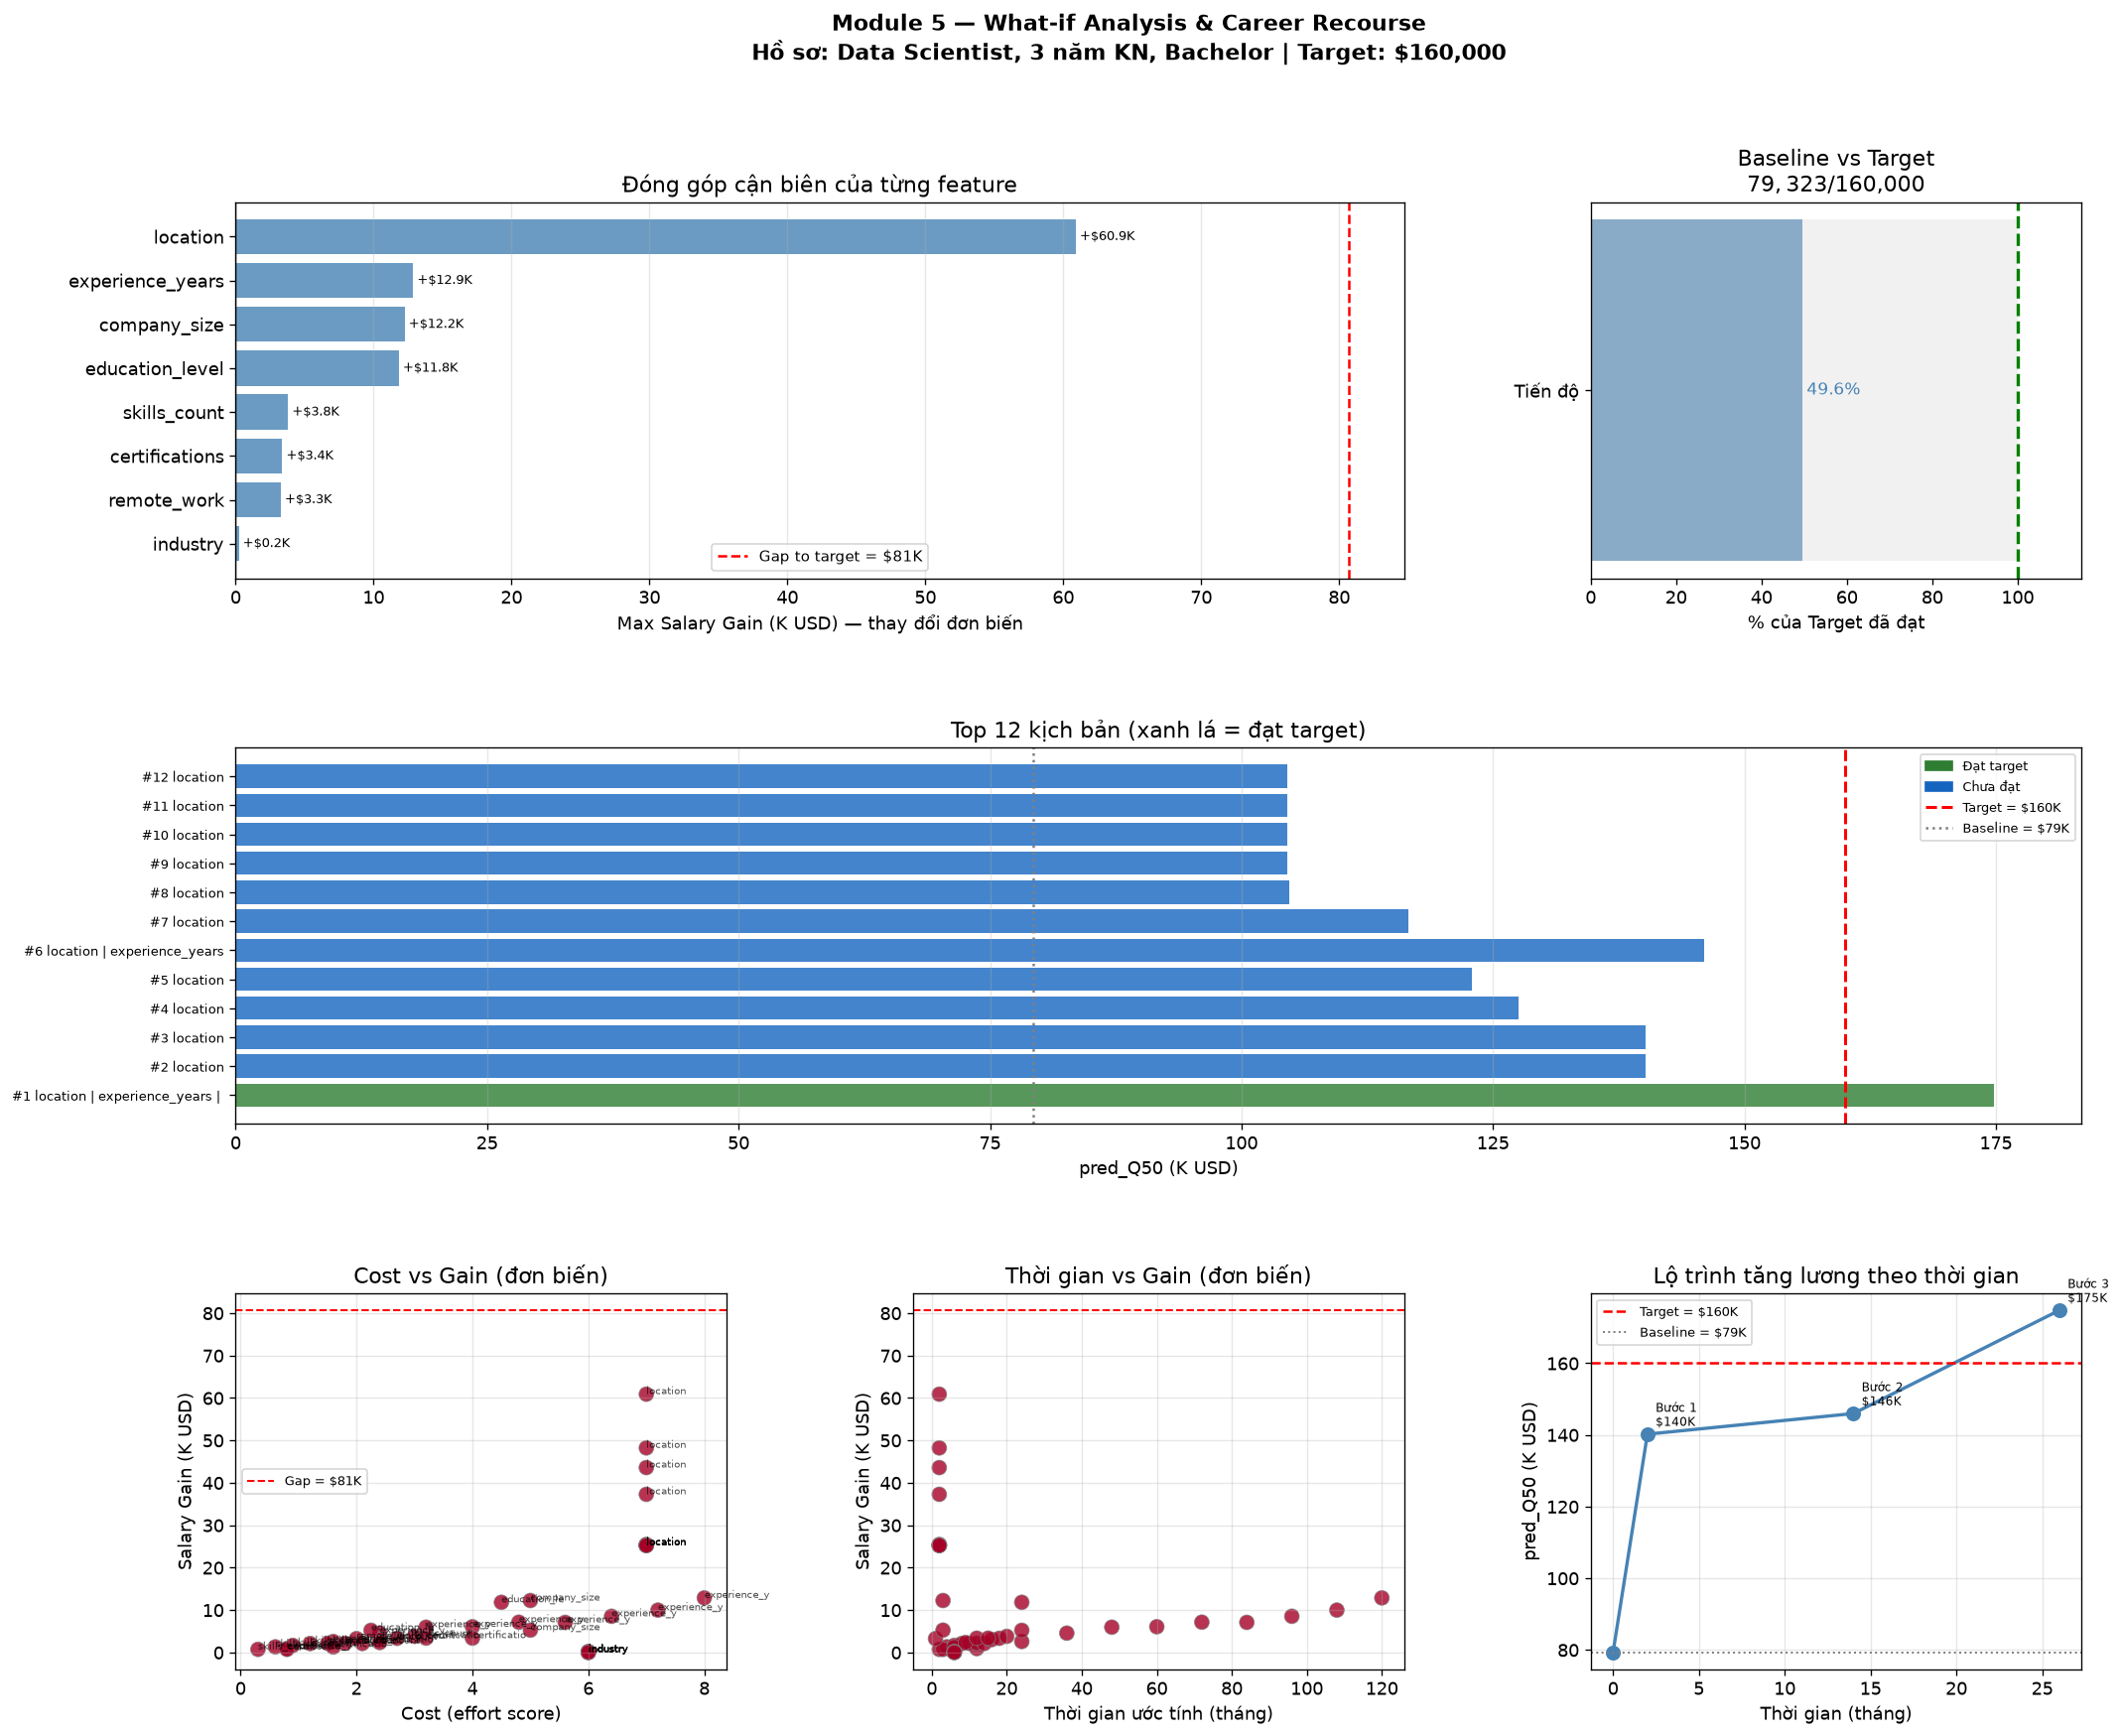

Đã lưu: figure/WhatIf/01_whatif_analysis.png


In [13]:
fig = plt.figure(figsize=(20, 16))
fig.suptitle(
    f'Module 5 — What-if Analysis & Career Recourse\n'
    f'Hồ sơ: {base_profile["job_title"]}, {base_profile["experience_years"]} năm KN, '
    f'{base_profile["education_level"]} | Target: ${target_salary:,.0f}',
    fontsize=13, fontweight='bold'
)

gs = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.38)
ax1 = fig.add_subplot(gs[0, :2])   # Salary gain per feature (wide)
ax2 = fig.add_subplot(gs[0, 2])    # Gap gauge
ax3 = fig.add_subplot(gs[1, :])    # Top-k scenarios bar chart
ax4 = fig.add_subplot(gs[2, 0])    # Cost vs Gain scatter
ax5 = fig.add_subplot(gs[2, 1])    # Time vs Gain scatter
ax6 = fig.add_subplot(gs[2, 2])    # Roadmap milestone

# ── VIZ 1: Max salary gain per feature ────────────────────────────────────────
if not df_single_valid.empty:
    feat_summary = (
        df_single_valid.groupby('features_changed')['salary_gain']
        .max()
        .sort_values(ascending=True)
    )
    colors_bar = ['#d32f2f' if g >= 0 else '#388e3c' for g in feat_summary.values]
    bars = ax1.barh(feat_summary.index, feat_summary.values / 1000,
                    color='steelblue', alpha=0.8)
    ax1.axvline(0, color='black', linewidth=0.8)
    ax1.axvline(salary_gap / 1000, color='red', linestyle='--',
                linewidth=1.5, label=f'Gap to target = ${salary_gap/1000:.0f}K')
    for bar, val in zip(bars, feat_summary.values):
        ax1.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                 f'+${val/1000:.1f}K', va='center', fontsize=8)
    ax1.set_xlabel('Max Salary Gain (K USD) — thay đổi đơn biến')
    ax1.set_title('Đóng góp cận biên của từng feature')
    ax1.legend(fontsize=9)
    ax1.grid(axis='x', alpha=0.3)

# ── VIZ 2: Gap gauge ──────────────────────────────────────────────────────────
gap_fill = min(baseline_Q50 / target_salary, 1.0)
ax2.barh(['Tiến độ'], [gap_fill * 100], color='steelblue', alpha=0.8, height=0.4)
ax2.barh(['Tiến độ'], [100], color='lightgrey', alpha=0.3, height=0.4)
ax2.axvline(100, color='green', linewidth=2, linestyle='--')
ax2.set_xlim(0, 115)
ax2.set_xlabel('% của Target đã đạt')
ax2.set_title(f'Baseline vs Target\n${baseline_Q50:,.0f} / ${target_salary:,.0f}')
ax2.text(gap_fill * 100 + 1, 0, f'{gap_fill*100:.1f}%', va='center', fontsize=10, color='steelblue')

# ── VIZ 3: Top-K scenario comparison ──────────────────────────────────────────
if not df_ranked.empty:
    top_k = min(12, len(df_ranked))
    df_top = df_ranked.head(top_k).copy()
    bar_colors = ['#2e7d32' if r else '#1565c0'
                  for r in df_top['reaches_target']]
    bars3 = ax3.barh(
        range(top_k),
        df_top['pred_Q50'].values / 1000,
        color=bar_colors, alpha=0.8
    )
    ax3.axvline(target_salary / 1000, color='red', linestyle='--',
                linewidth=1.8, label=f'Target = ${target_salary/1000:.0f}K')
    ax3.axvline(baseline_Q50 / 1000, color='grey', linestyle=':',
                linewidth=1.5, label=f'Baseline = ${baseline_Q50/1000:.0f}K')
    ax3.set_yticks(range(top_k))
    ax3.set_yticklabels(
        [f"#{r['rank']} {r['features_changed'][:30]}" for _, r in df_top.iterrows()],
        fontsize=8
    )
    ax3.set_xlabel('pred_Q50 (K USD)')
    ax3.set_title(f'Top {top_k} kịch bản (xanh lá = đạt target)')
    ax3.legend(fontsize=9)
    ax3.grid(axis='x', alpha=0.3)
    green_patch = mpatches.Patch(color='#2e7d32', label='Đạt target')
    blue_patch  = mpatches.Patch(color='#1565c0', label='Chưa đạt')
    ax3.legend(handles=[green_patch, blue_patch] +
               ax3.get_legend_handles_labels()[0][-2:], fontsize=8)

# ── VIZ 4: Cost vs Gain scatter ───────────────────────────────────────────────
if not df_single_valid.empty:
    sc = ax4.scatter(
        df_single_valid['cost_score'],
        df_single_valid['salary_gain'] / 1000,
        c=df_single_valid['reaches_target'].astype(int),
        cmap='RdYlGn', vmin=0, vmax=1,
        s=80, alpha=0.8, edgecolors='grey', linewidth=0.5
    )
    ax4.axhline(salary_gap / 1000, color='red', linestyle='--',
                linewidth=1.2, label=f'Gap = ${salary_gap/1000:.0f}K')
    ax4.set_xlabel('Cost (effort score)')
    ax4.set_ylabel('Salary Gain (K USD)')
    ax4.set_title('Cost vs Gain (đơn biến)')
    ax4.legend(fontsize=8)
    ax4.grid(alpha=0.3)
    for _, row_ in df_single_valid.iterrows():
        ax4.annotate(
            row_['features_changed'][:12],
            (row_['cost_score'], row_['salary_gain'] / 1000),
            fontsize=6, alpha=0.7
        )

# ── VIZ 5: Time vs Gain scatter ───────────────────────────────────────────────
if not df_single_valid.empty:
    ax5.scatter(
        df_single_valid['time_months'],
        df_single_valid['salary_gain'] / 1000,
        c=df_single_valid['reaches_target'].astype(int),
        cmap='RdYlGn', vmin=0, vmax=1,
        s=80, alpha=0.8, edgecolors='grey', linewidth=0.5
    )
    ax5.axhline(salary_gap / 1000, color='red', linestyle='--', linewidth=1.2)
    ax5.set_xlabel('Thời gian ước tính (tháng)')
    ax5.set_ylabel('Salary Gain (K USD)')
    ax5.set_title('Thời gian vs Gain (đơn biến)')
    ax5.grid(alpha=0.3)

# ── VIZ 6: Roadmap milestone ──────────────────────────────────────────────────
if roadmap and roadmap.get('milestones'):
    ms_list = roadmap['milestones']
    times   = [0] + [ms['cumulative_months'] for ms in ms_list]
    salaries= [baseline_Q50] + [ms['pred_q50'] for ms in ms_list]
    ax6.plot(times, [s / 1000 for s in salaries],
             marker='o', color='steelblue', linewidth=2, markersize=8)
    ax6.axhline(target_salary / 1000, color='red', linestyle='--',
                linewidth=1.5, label=f'Target = ${target_salary/1000:.0f}K')
    ax6.axhline(baseline_Q50 / 1000, color='grey', linestyle=':',
                linewidth=1.2, label=f'Baseline = ${baseline_Q50/1000:.0f}K')
    for ms in ms_list:
        ax6.annotate(
            f"Bước {ms['step']}\n${ms['pred_q50']/1000:.0f}K",
            (ms['cumulative_months'], ms['pred_q50'] / 1000),
            textcoords='offset points', xytext=(5, 5), fontsize=7
        )
    ax6.set_xlabel('Thời gian (tháng)')
    ax6.set_ylabel('pred_Q50 (K USD)')
    ax6.set_title('Lộ trình tăng lương theo thời gian')
    ax6.legend(fontsize=8)
    ax6.grid(alpha=0.3)
else:
    ax6.text(0.5, 0.5, 'Không có\nlộ trình\ntổ hợp',
             ha='center', va='center', transform=ax6.transAxes, fontsize=12)
    ax6.set_title('Lộ trình tăng lương')

plt.savefig(f'{FIGURE_DIR}/01_whatif_analysis.png', bbox_inches='tight')
plt.show()
print(f"Đã lưu: {FIGURE_DIR}/01_whatif_analysis.png")


## 12. Bước 10 — Export kết quả cho chatbot / giải thích

Toàn bộ kết quả được xuất ra:

| File | Nội dung |
|---|---|
| `whatif_scenarios.csv` | Tất cả kịch bản đã xếp hạng |
| `whatif_roadmap.json` | Lộ trình hành động theo phase |
| `whatif_report.json` | Báo cáo tổng hợp dạng structured — dùng cho chatbot |
| `whatif_top_single.csv` | Top kịch bản đơn biến |


In [14]:
# ── 1. Lưu tất cả kịch bản đã xếp hạng ─────────────────────────────────────
export_cols = [c for c in [
    'rank', 'scenario_type', 'features_changed', 'n_changes',
    'old_value', 'new_value', 'delta',
    'pred_Q50', 'pred_Q10', 'pred_Q90',
    'salary_gain', 'salary_gain_pct', 'reaches_target',
    'cost_score', 'time_months', 'recourse_score'
] if c in df_ranked.columns]

df_ranked[export_cols].to_csv(f'{OUTPUT_DIR}/whatif_scenarios.csv', index=False)
print(f"Đã lưu: {OUTPUT_DIR}/whatif_scenarios.csv  ({len(df_ranked)} kịch bản)")

# ── 2. Lưu roadmap JSON ──────────────────────────────────────────────────────
def make_json_safe(obj):
    """Chuyển numpy types → Python native để JSON serialize được."""
    if isinstance(obj, dict):
        return {k: make_json_safe(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [make_json_safe(i) for i in obj]
    elif isinstance(obj, (np.integer,)):
        return int(obj)
    elif isinstance(obj, (np.floating,)):
        return float(obj)
    elif isinstance(obj, (np.bool_,)):
        return bool(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

with open(f'{OUTPUT_DIR}/whatif_roadmap.json', 'w', encoding='utf-8') as f:
    json.dump(make_json_safe(roadmap), f, ensure_ascii=False, indent=2)
print(f"Đã lưu: {OUTPUT_DIR}/whatif_roadmap.json")

# ── 3. Lưu report tổng hợp cho chatbot ──────────────────────────────────────
top3_scenarios = []
for _, row_ in df_ranked.head(3).iterrows():
    top3_scenarios.append({
        'rank'            : int(row_['rank']),
        'features_changed': str(row_['features_changed']),
        'pred_Q50'        : float(row_['pred_Q50']),
        'salary_gain'     : float(row_['salary_gain']),
        'salary_gain_pct' : float(row_['salary_gain_pct']),
        'reaches_target'  : bool(row_['reaches_target']),
        'cost_score'      : float(row_['cost_score']),
        'time_months'     : float(row_['time_months']),
        'recourse_score'  : float(row_['recourse_score']),
    })

report = {
    'module'           : 'What-if Analysis & Career Recourse',
    'base_profile'     : base_profile,
    'target_salary'    : float(target_salary),
    'baseline'         : {
        'pred_Q50'     : float(baseline_Q50),
        'pred_Q10'     : float(baseline_Q10),
        'pred_Q90'     : float(baseline_Q90),
        'peer_median'  : float(baseline_peer),
        'salary_gap'   : float(salary_gap),
        'gap_pct'      : float(gap_pct),
    },
    'needs_recourse'   : bool(NEEDS_RECOURSE),
    'top3_scenarios'   : top3_scenarios,
    'roadmap_summary'  : {
        'total_time_months'  : float(roadmap.get('total_time', 0)),
        'total_effort_score' : float(roadmap.get('total_cost', 0)),
        'final_q50_estimate' : float(roadmap.get('final_q50', baseline_Q50)),
        'n_phases'           : len(roadmap.get('phases', [])),
        'n_milestones'       : len(roadmap.get('milestones', [])),
    } if roadmap else {},
    'chatbot_summary'  : (
        f"Hồ sơ {base_profile['job_title']} hiện tại có Q50 = ${baseline_Q50:,.0f}. "
        f"Để đạt target ${target_salary:,.0f} (gap {gap_pct:+.1f}%), "
        f"khuyến nghị: {top3_scenarios[0]['features_changed'] if top3_scenarios else 'N/A'}. "
        f"Lộ trình ước tính: {roadmap.get('total_time', 0):.0f} tháng."
        if top3_scenarios else
        f"Q50 hiện tại (${baseline_Q50:,.0f}) đã đạt target (${target_salary:,.0f})."
    ),
}

with open(f'{OUTPUT_DIR}/whatif_report.json', 'w', encoding='utf-8') as f:
    json.dump(make_json_safe(report), f, ensure_ascii=False, indent=2)
print(f"Đã lưu: {OUTPUT_DIR}/whatif_report.json")

# ── 4. Top single-feature scenarios ──────────────────────────────────────────
if not df_single_valid.empty:
    top_single = df_single_valid.nlargest(20, 'salary_gain')[export_cols if all(c in df_single_valid.columns for c in export_cols) else df_single_valid.columns.tolist()]
    top_single.to_csv(f'{OUTPUT_DIR}/whatif_top_single.csv', index=False)
    print(f"Đã lưu: {OUTPUT_DIR}/whatif_top_single.csv")

print()
print("=" * 60)
print("  ✅ Module 5 — Export hoàn tất")
print("=" * 60)
print(f"  {OUTPUT_DIR}/whatif_scenarios.csv   — tất cả kịch bản")
print(f"  {OUTPUT_DIR}/whatif_roadmap.json    — lộ trình hành động")
print(f"  {OUTPUT_DIR}/whatif_report.json     — báo cáo chatbot")
print(f"  {OUTPUT_DIR}/whatif_top_single.csv  — top đơn biến")


Đã lưu: whatif_outputs/whatif_scenarios.csv  (48 kịch bản)
Đã lưu: whatif_outputs/whatif_roadmap.json
Đã lưu: whatif_outputs/whatif_report.json
Đã lưu: whatif_outputs/whatif_top_single.csv

  ✅ Module 5 — Export hoàn tất
  whatif_outputs/whatif_scenarios.csv   — tất cả kịch bản
  whatif_outputs/whatif_roadmap.json    — lộ trình hành động
  whatif_outputs/whatif_report.json     — báo cáo chatbot
  whatif_outputs/whatif_top_single.csv  — top đơn biến


## 13. Demo: Pipeline đầu đến cuối cho hồ sơ mới

Hàm `run_whatif_pipeline()` đóng gói toàn bộ Module 5 thành một lời gọi duy nhất —
thích hợp để tích hợp vào chatbot hoặc giao diện tương tác.


In [15]:
def run_whatif_pipeline(
    profile          : dict,
    target_salary    : float,
    max_features     : int = 4,
    verbose          : bool = True,
) -> dict:
    """
    Pipeline đầu đến cuối: hồ sơ + target → recourse report.

    Parameters
    ----------
    profile       : hồ sơ ứng viên (9 fields)
    target_salary : mức lương mục tiêu (USD)
    max_features  : số feature tối đa trong tổ hợp
    verbose       : in kết quả ra màn hình

    Returns
    -------
    dict: baseline, top_scenarios, roadmap, chatbot_summary
    """
    # Bước 1–2: baseline
    bl = predict_salary_full(
        profile=profile, preprocessor=preprocessor,
        model_lgbm=model_lgbm, model_lgbm_p10=model_lgbm_p10,
        model_lgbm_p50=model_lgbm_p50, model_lgbm_p90=model_lgbm_p90,
        knn_scaler=knn_scaler, knn_nn_engine=knn_nn_engine,
        y_train_salary=y_train,
    )
    q50_base = bl['pred_Q50']
    gap      = target_salary - q50_base

    # Bước 3: kiểm tra
    if q50_base >= target_salary * (1 - TOLERANCE):
        return {
            'needs_recourse': False,
            'baseline_q50'  : q50_base,
            'message'       : f"Q50 (${q50_base:,.0f}) đã đạt target (${target_salary:,.0f})."
        }

    # Bước 5: đơn biến
    df_s = generate_single_feature_scenarios(
        profile, ACTIONABLE_SPACE, predict_fn, q50_base, target_salary
    )
    df_s = filter_valid_scenarios(df_s, profile)

    # Bước 6: tổ hợp
    combos = greedy_counterfactual_search(
        profile, ACTIONABLE_SPACE, predict_fn, q50_base, target_salary, max_features
    )
    df_c = pd.DataFrame([{k: v for k, v in s.items() if k != 'modified_profile'}
                          for s in combos])
    if not df_c.empty:
        df_c = filter_valid_scenarios(df_c, profile)

    # Bước 7–8: filter + rank
    df_all = pd.concat([df_s, df_c] if not df_c.empty else [df_s], ignore_index=True)
    df_r   = rank_scenarios(df_all, q50_base, target_salary)

    # Bước 9: roadmap
    rm = build_action_roadmap(combos, profile, q50_base, target_salary)

    top3 = df_r.head(3).to_dict('records')

    if verbose:
        print(f"\n{'='*55}")
        print(f"  What-if Report — {profile.get('job_title','N/A')}")
        print(f"{'='*55}")
        print(f"  Baseline Q50 : ${q50_base:,.0f}")
        print(f"  Target       : ${target_salary:,.0f}  (gap {gap/q50_base*100:+.1f}%)")
        print(f"  Top recommendation: {top3[0]['features_changed'] if top3 else 'N/A'}")
        if rm:
            print(f"  Roadmap      : {rm.get('total_time',0):.0f} tháng, "
                  f"effort={rm.get('total_cost',0):.0f}/50")
        print(f"{'='*55}")

    return {
        'needs_recourse' : True,
        'baseline'       : bl,
        'top_scenarios'  : top3,
        'roadmap'        : rm,
        'all_scenarios'  : df_r,
    }


# ── Demo với hồ sơ khác ───────────────────────────────────────────────────────
demo_profile = {
    'job_title'       : 'Backend Developer',
    'experience_years': 2,
    'education_level' : 'Bachelor',
    'skills_count'    : 4,
    'industry'        : 'Retail',
    'company_size'    : 'Small',
    'location'        : 'India',
    'remote_work'     : 'No',
    'certifications'  : 0,
}

demo_result = run_whatif_pipeline(
    profile       = demo_profile,
    target_salary = 130_000,
    verbose       = True,
)


  Constraint filter: 51 → 40 kịch bản hợp lệ
  Constraint filter: 2 → 2 kịch bản hợp lệ

  What-if Report — Backend Developer
  Baseline Q50 : $67,451
  Target       : $130,000  (gap +92.7%)
  Top recommendation: location | company_size
  Roadmap      : 5 tháng, effort=12/50


## 14. Tóm tắt Module 5

### Những gì đã thực hiện

| Bước | Nội dung | Phương pháp |
|---|---|---|
| 1–3 | Nhận hồ sơ, tính baseline Q50, phát hiện gap | Module 1 pipeline |
| 4 | Định nghĩa actionable space + cost/time | Domain knowledge |
| 5 | Single-feature perturbation | Brute-force trên không gian đơn biến |
| 6 | Multi-feature counterfactual | Greedy Forward Search (gain/cost heuristic) |
| 7 | Constraint filtering | Hard constraints (increase-only, valid values) |
| 8 | Ranking | Composite score: α·gain − β·cost − γ·time + feasibility bonus |
| 9 | Action Roadmap | Phase allocation (short/medium/long-term) |
| 10 | Export | CSV + JSON cho chatbot integration |

### File đầu ra

```
whatif_outputs/
├── whatif_scenarios.csv     — tất cả kịch bản đã xếp hạng
├── whatif_roadmap.json      — lộ trình theo phase
├── whatif_report.json       — structured report cho chatbot
├── whatif_top_single.csv    — top kịch bản đơn biến
figure/WhatIf/
└── 01_whatif_analysis.png   — biểu đồ tổng hợp 6 panels
```

### Dependency Pipeline

```
preprocessing_salary_outputs/ → Module 1 (LGBM) → Module 2 (KNN)
                                      ↓
                              Module 5 (What-if)
                              ├── single-feature perturbation
                              ├── greedy counterfactual search
                              └── action roadmap → chatbot JSON
```
